# PINN pro Wurf (Architektur B): θ und v₀ als trainierbare Parameter
Dieses Notebook implementiert eine **echte PINN-Variante pro Wurf**:

- Das Netz lernt **(x(t), y(t)) = f_φ(t)**.
- Die Parameter **θ** (Wurfwinkel) und **v₀** (Anfangsgeschwindigkeit) sind **trainierbare Skalare** (`nn.Parameter`) und **nicht** Teil des Netzeingangs.
- Physik wird über Residuen erzwungen:
  - x'(t) = v₀ cos(θ)
  - y'(t) = v₀ sin(θ) − g t

Am Ende bekommst du: geschätzte θ, v₀ und eine rekonstruierte Bahn.


In [51]:
# === Setup ===
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Daten laden
CSV: `free_throw_clean_dataset.csv`.
Wir wählen anschließend **einen** `wurf_id` zum Fitten aus.


In [52]:
csv_path = "free_throw_clean_dataset.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (7500, 12)
Columns: ['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0
0,0,0.000000,0.000000,2.662500,0.000000,2.662500,0.000000,2.662500,0.995387,2,0.795079,7.379223
1,0,0.020314,0.104965,2.767494,0.104965,2.767494,0.104965,2.767494,0.995387,2,0.795079,7.379223
2,0,0.040628,0.209931,2.868441,0.209931,2.868441,0.209931,2.868441,0.995387,2,0.795079,7.379223
3,0,0.060942,0.314896,2.965342,0.314896,2.965342,0.314896,2.965342,0.995387,2,0.795079,7.379223
4,0,0.081256,0.419862,3.058195,0.419862,3.058195,0.419862,3.058195,0.995387,2,0.795079,7.379223


In [53]:
# === Wurf auswählen ===
wurf_id = int(df["wurf_id"].iloc[0])  # ändere das für andere Würfe

df_wurf = df[df["wurf_id"] == wurf_id].sort_values("t").reset_index(drop=True)

print("wurf_id:", wurf_id)
print("N Punkte:", len(df_wurf))
df_wurf.head()


wurf_id: 0
N Punkte: 50


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0
0,0,0.000000,0.000000,2.662500,0.000000,2.662500,0.000000,2.662500,0.995387,2,0.795079,7.379223
1,0,0.020314,0.104965,2.767494,0.104965,2.767494,0.104965,2.767494,0.995387,2,0.795079,7.379223
2,0,0.040628,0.209931,2.868441,0.209931,2.868441,0.209931,2.868441,0.995387,2,0.795079,7.379223
3,0,0.060942,0.314896,2.965342,0.314896,2.965342,0.314896,2.965342,0.995387,2,0.795079,7.379223
4,0,0.081256,0.419862,3.058195,0.419862,3.058195,0.419862,3.058195,0.995387,2,0.795079,7.379223


Optional: Nur die ersten `n_obs` Punkte verwenden (partial observation). Für alle Punkte: `n_obs=None`.


In [54]:
n_obs = 30  # None => alle Punkte
df_obs = df_wurf.copy() if n_obs is None else df_wurf.iloc[:n_obs].copy()

t_obs_np = df_obs["t"].to_numpy(dtype=np.float32)
x_obs_np = df_obs["x"].to_numpy(dtype=np.float32)
y_obs_np = df_obs["y"].to_numpy(dtype=np.float32)

t_min = float(df_wurf["t"].min())
t_max_full = float(df_wurf["t"].max())

t_obs_max = float(df_obs["t"].max())  # letzter beobachteter Zeitpunkt (bekannt)

t_min, t_obs_max, t_max_full, len(df_obs)


(0.0, 0.5891066789627075, 0.9953871369361876, 30)

## 2) Physik-Konstanten
Konsistent mit dem Datensatz (ballistisch, ohne Luftwiderstand).


In [55]:
g = 9.807
hs = 2.13
y0 = float(df_wurf.sort_values("t")["y"].iloc[0])
hKorb = 3.048

g, y0

(9.807, 2.6624999046325684)

## 3) PINN: fφ(t) → (x,y), θ und v₀ als Parameter
Input ist **nur t**. θ und v₀ werden als `nn.Parameter` gelernt.

Parametrisierung:
- θ = (π/2) * sigmoid(θ_raw)  ⇒ θ ∈ (0, π/2)
- v₀ = softplus(v0_raw) + eps ⇒ v₀ > 0


In [56]:
class MLP(nn.Module):
    def __init__(self, hidden=128, depth=4):
        super().__init__()
        layers = []
        in_dim = 1
        for _ in range(depth):
            layers += [nn.Linear(in_dim, hidden), nn.Tanh()]
            in_dim = hidden
        layers.append(nn.Linear(in_dim, 2))  # x,y
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)

class ThrowPINN(nn.Module):
    def __init__(self, hidden=128, depth=4, v0_eps=1e-3):
        super().__init__()
        self.f = MLP(hidden=hidden, depth=depth)
        self.theta_raw = nn.Parameter(torch.tensor(0.0))
        self.v0_raw = nn.Parameter(torch.tensor(1.0))
        self.v0_eps = v0_eps

    def theta(self):
        return (math.pi / 2.0) * torch.sigmoid(self.theta_raw)

    def v0(self):
        return torch.nn.functional.softplus(self.v0_raw) + self.v0_eps

    def forward(self, t):
        return self.f(t)

model = ThrowPINN(hidden=128, depth=4).to(device)
model


ThrowPINN(
  (f): MLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): Tanh()
      (6): Linear(in_features=128, out_features=128, bias=True)
      (7): Tanh()
      (8): Linear(in_features=128, out_features=2, bias=True)
    )
  )
)

## 4) Loss: Daten + Physik + Initialbedingung
Physik-Residuals nutzen Ableitungen per Autograd.


In [57]:
mse = nn.MSELoss()


def physics_residuals(model, t_real, t_min, t_scale, g):
    """Physik-Residuals für ballistische Bewegung (ohne Luftwiderstand).

    Wichtig:
    - Das Netz bekommt normierte Zeit t_n = (t_real - t_min) / t_scale.
    - Ableitungen werden bzgl. t_real gebildet (autograd berücksichtigt die Skalierung korrekt).
    """
    t_real = t_real.clone().detach().requires_grad_(True)

    # t_n liegt für Beobachtungen in [0,1]; bei Extrapolation > 1
    t_n = (t_real - t_min) / (t_scale + 1e-12)

    out = model(t_n)
    x = out[:, 0:1]
    y = out[:, 1:2]

    x_t = torch.autograd.grad(
        x, t_real, torch.ones_like(x), create_graph=True, retain_graph=True
    )[0]
    y_t = torch.autograd.grad(
        y, t_real, torch.ones_like(y), create_graph=True, retain_graph=True
    )[0]

    theta = model.theta()
    v0 = model.v0()

    # Annahme: t=0 beim Abwurf (oder allgemein: Beschleunigung wirkt auf (t_real - t_min))
    tau = t_real - t_min

    r_x = x_t - v0 * torch.cos(theta)
    r_y = y_t - (v0 * torch.sin(theta) - g * tau)
    return r_x, r_y


def time_to_height(theta, v0, y0, h_target, g, prefer_descending=True):
    """Schätzt die Zeit t>0, bei der y(t)=h_target im reinen Ballistik-Modell gilt.

    y(t) = y0 + v0*sin(theta)*t - 0.5*g*t^2

    Rückgabe:
        - Tensor-Skalar t (kann NaN sein, falls keine reale Lösung existiert)
    """
    v0s = v0 * torch.sin(theta)
    disc = v0s.pow(2) - 2.0*g*(h_target - y0)
    if torch.any(disc < 0):
        return torch.tensor(float("nan"), device=disc.device)
    sqrt_disc = torch.sqrt(disc)


    t1 = (v0s - sqrt_disc) / (g + 1e-12)
    t2 = (v0s + sqrt_disc) / (g + 1e-12)

    if prefer_descending:
        # i.d.R. ist der Korb beim absteigenden Ast relevant -> größere Lösung
        t_hit = torch.maximum(t1, t2)
    else:
        # alternativ: erste Kreuzung (aufsteigend)
        t_hit = torch.minimum(t1, t2)

    return t_hit


def initial_condition_loss(model: ThrowPINN, y0: float, t0_real: float, t_min, t_scale):
    """Startbedingung am realen Zeitpunkt t0_real (typisch 0.0)."""
    t0_real_t = torch.tensor([[t0_real]], device=device)
    t0_n = (t0_real_t - t_min) / (t_scale + 1e-12)
    out0 = model(t0_n)
    x0 = out0[:, 0]
    y0_hat = out0[:, 1]
    return (x0 - 0.0).pow(2).mean() + (y0_hat - y0).pow(2).mean()


## 5) Training
Wir optimieren Netzegewichte **und** θ, v₀ gemeinsam.


In [58]:
# === Torch-Daten ===
t_obs = torch.tensor(t_obs_np, device=device).view(-1, 1)
x_obs = torch.tensor(x_obs_np, device=device).view(-1, 1)
y_obs = torch.tensor(y_obs_np, device=device).view(-1, 1)

# === Option 3: Extrapolation bis zur Korbhöhe (ohne Leakage von t_max aus der Zukunft) ===
# Wir skalieren die Zeit nur mit dem letzten beobachteten Zeitpunkt (bekannt):
#   t_n = (t - t_min) / (t_obs_max - t_min)
# Damit liegen Beobachtungen in [0,1] und Zukunft liegt bei t_n > 1.
t_min_t = torch.tensor(t_min, device=device)
t_obs_max_t = torch.tensor(t_obs_max, device=device)
t_scale_t = (t_obs_max_t - t_min_t).clamp_min(1e-12)

def norm_t(t):
    return (t - t_min_t) / t_scale_t

t_obs_n = norm_t(t_obs)

# Collocation: bis zur (geschätzten) Zeit, zu der y(t)=Korbhöhe erreicht wird.
n_coll = 300

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

w_data, w_phys, w_ic = 1.0, 1.0, 10.0
num_steps = 10000
log_every = 250

# Sicherheitsgrenzen (damit Collocation nicht "explodiert", falls der Schätzer kurzzeitig Unsinn liefert)
t_extra_min = 0.25     # mindestens so weit in die Zukunft über t_obs_max hinaus
t_extra_max = 3.00     # höchstens so weit in die Zukunft über t_obs_max hinaus

history = {"loss": [], "data": [], "phys": [], "ic": [], "theta": [], "v0": [], "t_end": []}

for step in range(1, num_steps + 1):
    opt.zero_grad()

    # --- Data loss (nur Beobachtungen) ---
    pred_obs = model(t_obs_n)
    loss_data = mse(pred_obs[:, 0:1], x_obs) + mse(pred_obs[:, 1:2], y_obs)

    # --- Dynamisches Collocation-Ende: bis zur Korbhöhe (aus aktuellem theta, v0) ---
    # Ballistik-Schätzer (ohne NN), i.d.R. absteigende Kreuzung mit der Korbhöhe.
    with torch.no_grad():
        t_hit = time_to_height(model.theta(), model.v0(), y0=y0, h_target=hKorb, g=g, prefer_descending=True)
        t_hit_val = float(t_hit.detach().cpu())

    # Fallback, falls keine reale Lösung oder numerisch instabil
    if (not math.isfinite(t_hit_val)) or (t_hit_val <= 0.0):
        t_end = float(t_obs_max) + t_extra_min
    else:
        t_end = max(float(t_obs_max), t_hit_val)

    # Clamp auf sinnvolles Extrapolationsfenster
    t_end = min(max(t_end, float(t_obs_max) + t_extra_min), float(t_obs_max) + t_extra_max)

    t_coll = torch.linspace(float(t_min), float(t_end), n_coll, device=device).view(-1, 1)

    # --- Physics loss (über Beobachtungen hinaus bis t_end) ---
    r_x, r_y = physics_residuals(model, t_coll, t_min=t_min_t, t_scale=t_scale_t, g=g)
    loss_phys = r_x.pow(2).mean() + r_y.pow(2).mean()

    # --- Initial condition am Abwurf (t=0) ---
    loss_ic = initial_condition_loss(model, y0=y0, t0_real=0.0, t_min=t_min_t, t_scale=t_scale_t)

    loss = w_data * loss_data + w_phys * loss_phys + w_ic * loss_ic
    loss.backward()
    opt.step()

    if step % log_every == 0 or step == 1:
        theta_deg = float(model.theta().detach().cpu() * 180.0 / math.pi)
        v0_val = float(model.v0().detach().cpu())
        print(
            f"step {step:5d} | loss={loss.item():.3e} | data={loss_data.item():.3e} | "
            f"phys={loss_phys.item():.3e} | ic={loss_ic.item():.3e} | "
            f"t_end={t_end:.3f}s | theta={theta_deg:.2f}° | v0={v0_val:.4f}"
        )

    history["loss"].append(float(loss.detach().cpu()))
    history["data"].append(float(loss_data.detach().cpu()))
    history["phys"].append(float(loss_phys.detach().cpu()))
    history["ic"].append(float(loss_ic.detach().cpu()))
    history["theta"].append(float(model.theta().detach().cpu()))
    history["v0"].append(float(model.v0().detach().cpu()))
    history["t_end"].append(float(t_end))


step     1 | loss=1.003e+02 | data=1.647e+01 | phys=1.610e+01 | ic=6.775e+00 | t_end=0.839s | theta=45.02° | v0=1.3150
step   250 | loss=3.244e+00 | data=2.561e+00 | phys=5.065e-01 | ic=1.768e-02 | t_end=0.839s | theta=45.51° | v0=1.4775
step   500 | loss=3.025e+00 | data=2.393e+00 | phys=4.673e-01 | ic=1.648e-02 | t_end=0.839s | theta=45.56° | v0=1.6732
step   750 | loss=2.808e+00 | data=2.222e+00 | phys=4.331e-01 | ic=1.527e-02 | t_end=0.839s | theta=45.58° | v0=1.8810
step  1000 | loss=2.591e+00 | data=2.051e+00 | phys=3.997e-01 | ic=1.409e-02 | t_end=0.839s | theta=45.58° | v0=2.0967
step  1250 | loss=2.380e+00 | data=1.880e+00 | phys=3.643e-01 | ic=1.351e-02 | t_end=0.839s | theta=45.58° | v0=2.3171
step  1500 | loss=2.175e+00 | data=1.715e+00 | phys=3.301e-01 | ic=1.299e-02 | t_end=0.839s | theta=45.58° | v0=2.5398
step  1750 | loss=1.979e+00 | data=1.564e+00 | phys=3.032e-01 | ic=1.118e-02 | t_end=0.839s | theta=45.57° | v0=2.7631
step  2000 | loss=1.792e+00 | data=1.419e+00 | p

## 6) Vergleich mit Ground Truth (aus dem Datensatz)


In [59]:
theta_true = float(df_wurf["theta"].iloc[0])
v0_true = float(df_wurf["v0"].iloc[0])

theta_hat = float(model.theta().detach().cpu())
v0_hat = float(model.v0().detach().cpu())

print("Ground truth:")
print(f"  theta_true = {theta_true:.6f} rad = {theta_true * 180/math.pi:.3f}°")
print(f"  v0_true    = {v0_true:.6f}")

print("\nEstimated (PINN):")
print(f"  theta_hat  = {theta_hat:.6f} rad = {theta_hat * 180/math.pi:.3f}°")
print(f"  v0_hat     = {v0_hat:.6f}")

print("\nAbsolute errors:")
print(f"  |theta_hat - theta_true| = {abs(theta_hat - theta_true):.6e} rad")
print(f"  |v0_hat - v0_true|       = {abs(v0_hat - v0_true):.6e}")


Ground truth:
  theta_true = 0.795079 rad = 45.555°
  v0_true    = 7.379223

Estimated (PINN):
  theta_hat  = 0.795255 rad = 45.565°
  v0_hat     = 7.365454

Absolute errors:
  |theta_hat - theta_true| = 1.762991e-04 rad
  |v0_hat - v0_true|       = 1.376974e-02


## 7) Plot: Daten vs. rekonstruierte Bahn


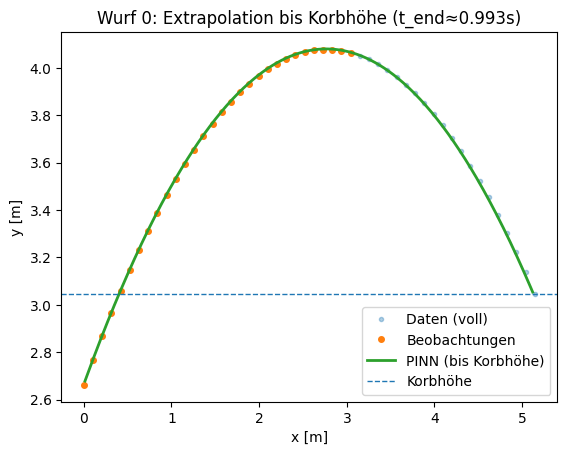

In [60]:
# Dichtes Grid für Vorhersage (bis zur Korbhöhe, gemäß aktuellem theta/v0)
with torch.no_grad():
    t_hit = time_to_height(model.theta(), model.v0(), y0=y0, h_target=hKorb, g=g, prefer_descending=True)
    t_hit_val = float(t_hit.detach().cpu())

if (not math.isfinite(t_hit_val)) or (t_hit_val <= 0.0):
    t_end_plot = float(t_obs_max) + 0.5
else:
    t_end_plot = max(float(t_obs_max), t_hit_val)

t_dense = torch.linspace(float(t_min), float(t_end_plot), 400, device=device).view(-1, 1)
t_dense_n = norm_t(t_dense)

with torch.no_grad():
    pred_dense = model(t_dense_n).cpu().numpy()

x_dense_hat = pred_dense[:, 0]
y_dense_hat = pred_dense[:, 1]

# echte Daten (voll) – nur zur Evaluation/Visualisierung
x_full = df_wurf["x"].to_numpy()
y_full = df_wurf["y"].to_numpy()

plt.figure()
plt.plot(x_full, y_full, ".", alpha=0.35, label="Daten (voll)")
plt.plot(x_obs_np, y_obs_np, "o", markersize=4, label="Beobachtungen")
plt.plot(x_dense_hat, y_dense_hat, "-", linewidth=2, label="PINN (bis Korbhöhe)")
plt.axhline(hKorb, linestyle="--", linewidth=1, label="Korbhöhe")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title(f"Wurf {wurf_id}: Extrapolation bis Korbhöhe (t_end≈{t_end_plot:.3f}s)")
plt.show()


## 8) Loss-Kurven (optional)


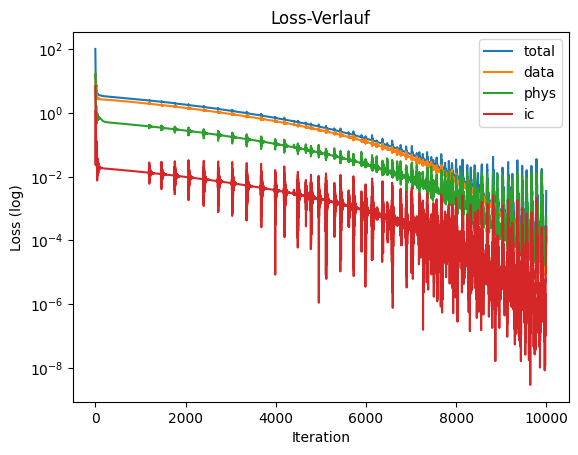

In [61]:
plt.figure()
plt.plot(history["loss"], label="total")
plt.plot(history["data"], label="data")
plt.plot(history["phys"], label="phys")
plt.plot(history["ic"], label="ic")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss (log)")
plt.legend()
plt.title("Loss-Verlauf")
plt.show()
